In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
df = pd.read_csv('student_performance_finalscore.csv')

In [3]:
df.head()

,Student_ID,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Final_Score
0,STU00001,17,Female,8.20,80.0,7.3,2.3,3.2,3.07,No,Online,Average,Average,Yes,3,High,1.8,87.10
1,STU00002,22,Male,4.07,69.2,7.9,3.6,0.5,2.66,Yes,Offline,Average,Good,No,2,Middle,1.0,92.03
2,STU00003,23,Female,5.07,74.2,6.7,2.6,4.7,3.27,No,Hybrid,Average,Good,No,1,Middle,4.2,95.37
3,STU00004,22,Female,5.82,82.5,3.7,3.3,2.3,2.87,No,Offline,Average,Excellent,No,0,Middle,3.6,90.73
4,STU00005,21,Male,3.42,90.8,7.4,7.0,3.1,2.82,Yes,Offline,Average,Good,No,2,Middle,4.5,74.71


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  8000 non-null   object 
 1   Age                         8000 non-null   int64  
 2   Gender                      8000 non-null   object 
 3   Hours_Studied               8000 non-null   float64
 4   Attendance                  8000 non-null   float64
 5   Sleep_Hours                 8000 non-null   float64
 6   Stress_Level                8000 non-null   float64
 7   Screen_Time                 8000 non-null   float64
 8   Previous_GPA                8000 non-null   float64
 9   Part_Time_Job               8000 non-null   object 
 10  Study_Method                8000 non-null   object 
 11  Diet_Quality                8000 non-null   object 
 12  Internet_Quality            8000 non-null   object 
 13  Extracurricular             8000 

In [5]:
df.describe()

,Age,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Tutoring_Sessions_Per_Week,Exam_Anxiety_Score,Final_Score
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,20.494375,4.983845,79.933375,6.989125,5.014175,4.024525,2.992408,1.700625,4.494238,83.205649
std,2.285962,1.951715,9.656594,1.192898,1.940126,1.481908,0.489530,1.112836,1.685571,12.756728
min,17.000000,0.020000,43.300000,3.000000,1.000000,0.500000,1.500000,0.000000,1.000000,22.810000
25%,18.000000,3.680000,73.400000,6.200000,3.700000,3.000000,2.670000,1.000000,3.300000,75.507500
50%,20.500000,4.980000,80.100000,7.000000,5.000000,4.000000,2.990000,2.000000,4.400000,86.510000
75%,22.000000,6.312500,86.600000,7.800000,6.300000,5.000000,3.330000,2.000000,5.600000,93.080000
max,24.000000,12.000000,100.000000,10.000000,10.000000,9.600000,6.700000,5.000000,10.000000,99.980000


In [6]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Hours_Studied,0
Attendance,0
Sleep_Hours,0
Stress_Level,0
Screen_Time,0
Previous_GPA,0
Part_Time_Job,0


In [7]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)

Index(['student_id', 'age', 'gender', 'hours_studied', 'attendance',
       'sleep_hours', 'stress_level', 'screen_time', 'previous_gpa',
       'part_time_job', 'study_method', 'diet_quality', 'internet_quality',
       'extracurricular', 'tutoring_sessions_per_week', 'family_income_level',
       'exam_anxiety_score', 'final_score'],
      dtype='object')


In [8]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [9]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
df = df.drop_duplicates()

In [11]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [12]:
target = "final_score"

In [13]:
if "student_id" in df.columns:
    df = df.drop("student_id", axis=1)

X = df.drop(target, axis=1)
y = df[target]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (6400, 16)
Test shape: (1600, 16)


In [17]:
df.to_csv('student_performance_finalscore_clean.csv', index=False)

In [18]:
import pandas as pd

# Membaca dataset
df = pd.read_csv("student_performance_finalscore_clean.csv")

# Kolom numerik
numeric_columns = [
    "hours_studied",
    "attendance",
    "sleep_hours",
    "screen_time",
    "previous_gpa",
    "stress_level",
    "exam_anxiety_score",
    "tutoring_sessions_per_week",
    "final_score"
]

# Mengecek jumlah outlier setiap kolom
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outlier")

hours_studied: 31 outlier
attendance: 32 outlier
sleep_hours: 40 outlier
screen_time: 27 outlier
previous_gpa: 39 outlier
stress_level: 0 outlier
exam_anxiety_score: 39 outlier
tutoring_sessions_per_week: 405 outlier
final_score: 115 outlier


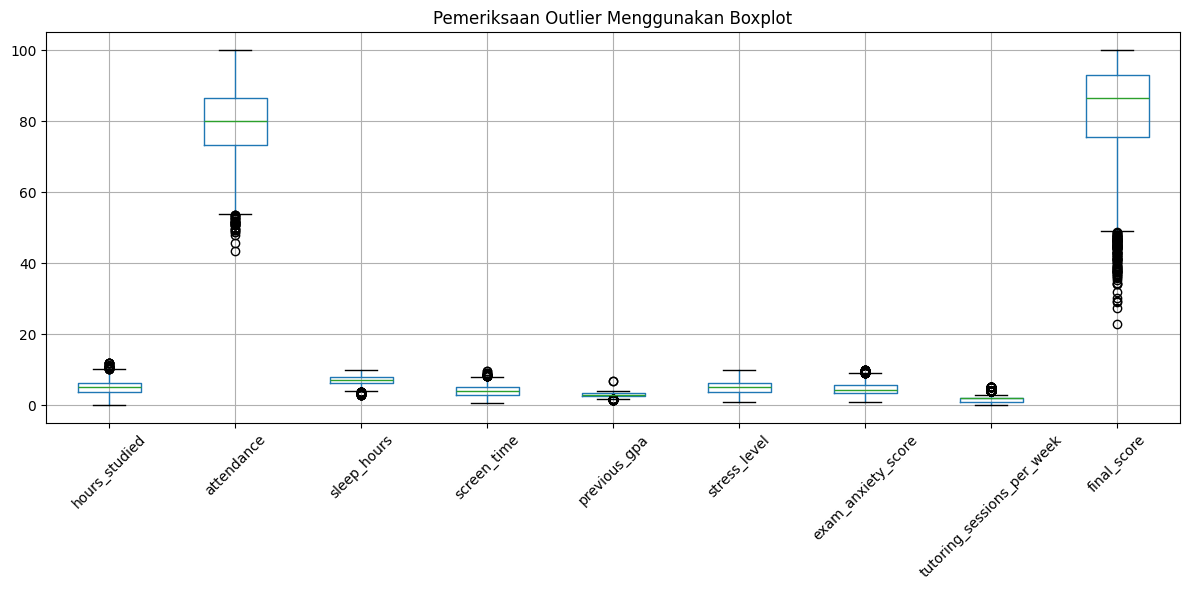

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df[numeric_columns].boxplot(rot=45)
plt.title("Pemeriksaan Outlier Menggunakan Boxplot")
plt.tight_layout()
plt.show()